
# Building a Fully Connected Neural Network for Devnagari Handwritten Digit Classification

##  Install / Import Libraries


In [1]:
import tensorflow as tf
print("TensorFlow version :", tf.__version__)
print("Keras version      :", tf.keras.__version__)

TensorFlow version : 2.19.0
Keras version      : 3.13.2


In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

print("All libraries imported successfully!")

All libraries imported successfully!



##  Upload and Extract the Devnagari Dataset



In [6]:
EXTRACT_DIR = "/content/devnagari"
zip_name = '/content/Copy of devnagari digit.zip'

with zipfile.ZipFile(zip_name, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

print(f"Extracted to: {EXTRACT_DIR}")

base = os.path.join(EXTRACT_DIR, "DevanagariHandwrittenDigitDataset")
for split in ["Train", "Test"]:
    split_path = os.path.join(base, split)
    classes = sorted(os.listdir(split_path))
    total = sum(len(os.listdir(os.path.join(split_path, c))) for c in classes)
    print(f"  {split}: {len(classes)} classes, {total} total images")

Extracted to: /content/devnagari
  Train: 10 classes, 17000 total images
  Test: 10 classes, 3000 total images


---
## Task 1 – Data Preparation



In [7]:
BASE_DIR  = "/content/devnagari/DevanagariHandwrittenDigitDataset"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
TEST_DIR  = os.path.join(BASE_DIR, "Test")

IMG_HEIGHT  = 28
IMG_WIDTH   = 28
NUM_CLASSES = 10


def load_images_from_folder(folder):

    images, labels = [], []

    class_names = sorted(os.listdir(folder))
    class_map   = {name: i for i, name in enumerate(class_names)}

    print(f"\nLoading from : {folder}")
    print(f"Classes      : {class_names}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")           # grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))          # 28 x 28
                img = np.array(img, dtype=np.float32) / 255.0     # normalise [0,1]
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"  Warning – skipping {img_path}: {e}")

    print(f"  Loaded {len(images)} images")
    return np.array(images), np.array(labels)


# Load Train and Test
x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR)
x_test_raw,  y_test_raw  = load_images_from_folder(TEST_DIR)

# Reshape for Keras
x_train = x_train_raw.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
x_test  = x_test_raw.reshape( -1, IMG_HEIGHT, IMG_WIDTH, 1)

# One-hot encode labels
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print("\n-- Dataset Shapes --")
print(f"x_train : {x_train.shape}   y_train : {y_train.shape}")
print(f"x_test  : {x_test.shape}    y_test  : {y_test.shape}")
print("\nPre-processing checklist:")
print("  Loaded images with PIL               v")
print("  Converted to grayscale               v")
print("  Resized to 28x28                     v")
print("  Normalised pixel values to [0, 1]    v")
print("  Labels extracted from folder names   v")
print("  One-hot encoded labels               v")
print("  Reshaped to (N, 28, 28, 1)           v")


Loading from : /content/devnagari/DevanagariHandwrittenDigitDataset/Train
Classes      : ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
  Loaded 17000 images

Loading from : /content/devnagari/DevanagariHandwrittenDigitDataset/Test
Classes      : ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
  Loaded 3000 images

-- Dataset Shapes --
x_train : (17000, 28, 28, 1)   y_train : (17000, 10)
x_test  : (3000, 28, 28, 1)    y_test  : (3000, 10)

Pre-processing checklist:
  Loaded images with PIL               v
  Converted to grayscale               v
  Resized to 28x28                     v
  Normalised pixel values to [0, 1]    v
  Labels extracted from folder names   v
  One-hot encoded labels               v
  Reshaped to (N, 28, 28, 1)           v


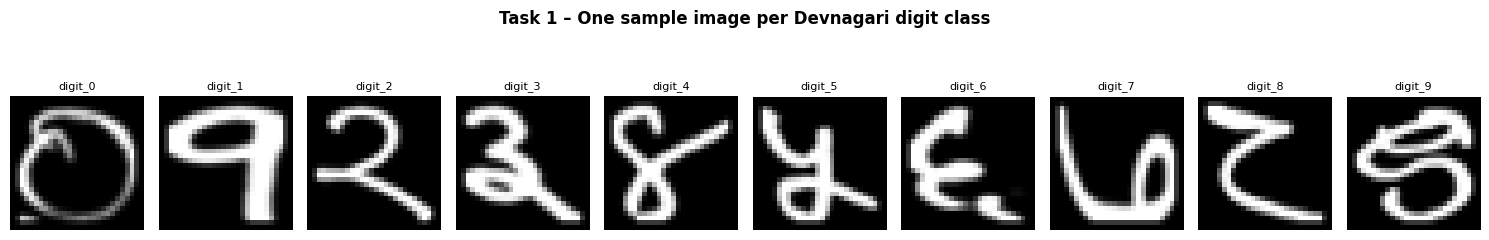

In [8]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2.5))
for i in range(10):

    idx = np.where(y_train_raw == i)[0][0]
    axes[i].imshow(x_train[idx].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    axes[i].set_title(f"digit_{i}", fontsize=8)
    axes[i].axis('off')

plt.suptitle("Task 1 – One sample image per Devnagari digit class",
             fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## Task 2 – Build the FCN Model (Sequential API)



In [10]:
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 1)

model = keras.Sequential(
    [

        keras.layers.Input(shape=INPUT_SHAPE),
        keras.layers.Flatten(name="flatten"),

        keras.layers.Dense(64,  activation="sigmoid", name="hidden_1"),

        keras.layers.Dense(128, activation="sigmoid", name="hidden_2"),

        keras.layers.Dense(256, activation="sigmoid", name="hidden_3"),

        keras.layers.Dense(NUM_CLASSES, activation="softmax", name="output"),
    ],
    name="FCN_Devnagari"
)

model.summary()

Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 3 – Compile the Model



In [11]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")
print("  Optimizer : Adam")
print("  Loss      : categorical_crossentropy")
print("  Metric    : accuracy")

Model compiled successfully!
  Optimizer : Adam
  Loss      : categorical_crossentropy
  Metric    : accuracy


---
## Task 4 – Train the Model



In [31]:
BATCH_SIZE = 128
EPOCHS     = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_devnagari_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

print(f"Training  ->  batch_size={BATCH_SIZE}, epochs={EPOCHS}, val_split=20%")

history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")

Training  ->  batch_size=128, epochs=20, val_split=20%
Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8092 - loss: 0.6432
Epoch 1: val_loss improved from None to 9.10700, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8354 - loss: 0.5090 - val_accuracy: 0.0000e+00 - val_loss: 9.1070
Epoch 2/20
 98/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8938 - loss: 0.3026
Epoch 2: val_loss did not improve from 9.10700
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9129 - loss: 0.2693 - val_accuracy: 0.0000e+00 - val_loss: 9.8798
Epoch 3/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9469 - loss: 0.1925
Epoch 3: val_loss did not improve from 9.10700
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9472 - loss: 0.1827 - val_accuracy: 0.0000e+00 - val_loss: 10.4007
Epoch 4/20
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9562 - lo

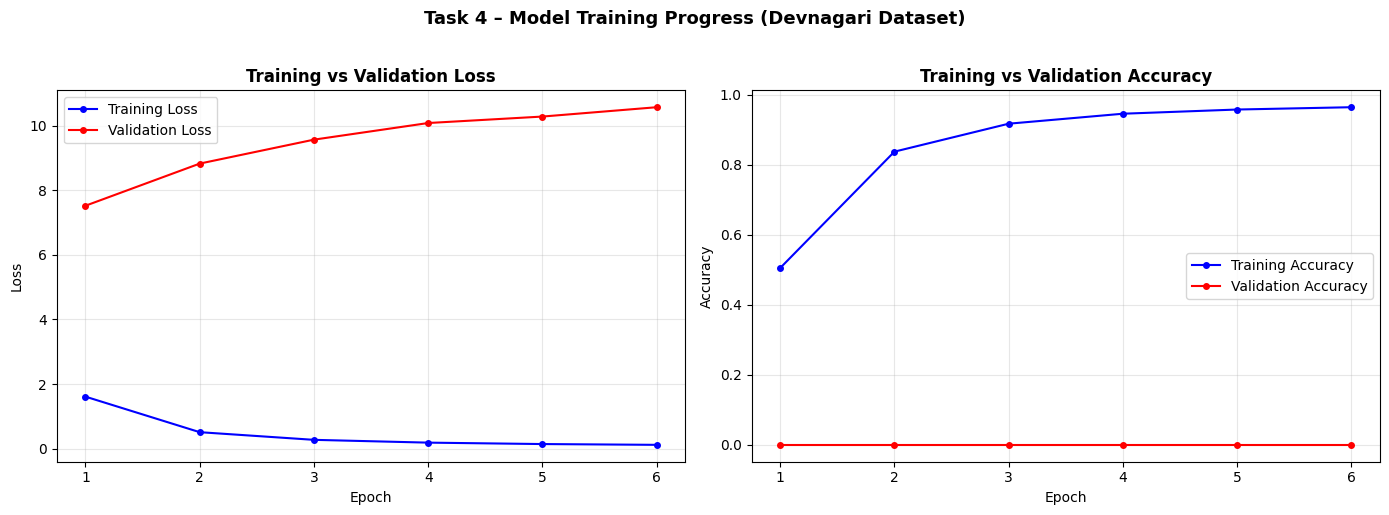

Epochs run              : 6 / 20
Final training loss     : 0.1208
Final training accuracy : 96.51%
Final val loss          : 10.5669
Final val accuracy      : 0.00%


In [13]:
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
ep_range   = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ep_range, train_loss, 'b-o', ms=4, label='Training Loss')
ax1.plot(ep_range, val_loss,   'r-o', ms=4, label='Validation Loss')
ax1.set_title('Training vs Validation Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep_range, train_acc, 'b-o', ms=4, label='Training Accuracy')
ax2.plot(ep_range, val_acc,   'r-o', ms=4, label='Validation Accuracy')
ax2.set_title('Training vs Validation Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Task 4 – Model Training Progress (Devnagari Dataset)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Epochs run              : {len(train_loss)} / {EPOCHS}")
print(f"Final training loss     : {train_loss[-1]:.4f}")
print(f"Final training accuracy : {train_acc[-1]*100:.2f}%")
print(f"Final val loss          : {val_loss[-1]:.4f}")
print(f"Final val accuracy      : {val_acc[-1]*100:.2f}%")


## Task 5 – Evaluate the Model



In [30]:
print("Evaluating on test set...\n")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")

Evaluating on test set...

94/94 - 0s - 4ms/step - accuracy: 0.6170 - loss: 2.1636
  Test Loss     : 2.1636
  Test Accuracy : 0.6170  (61.70%)


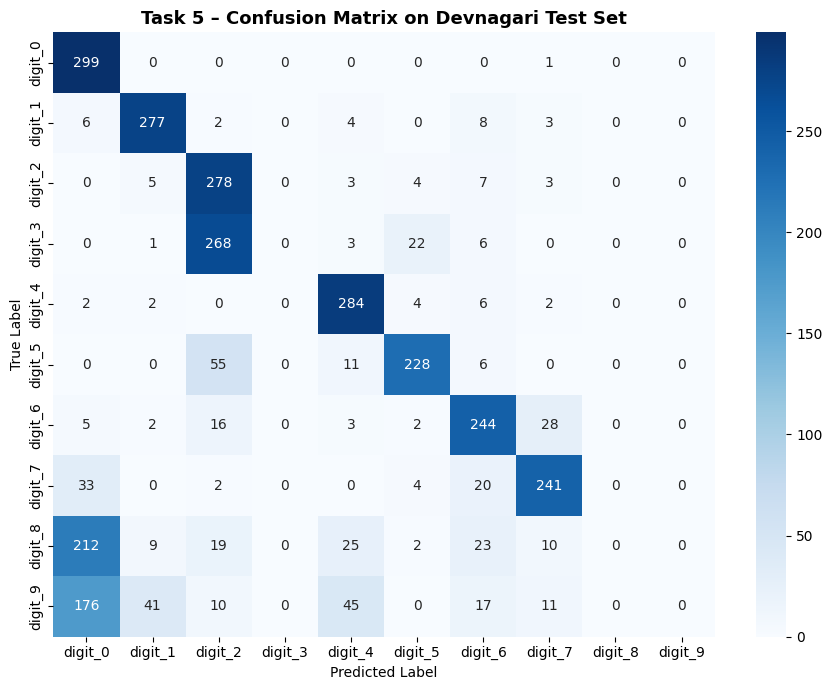


Classification Report:
              precision    recall  f1-score   support

     digit_0       0.41      1.00      0.58       300
     digit_1       0.82      0.92      0.87       300
     digit_2       0.43      0.93      0.59       300
     digit_3       0.00      0.00      0.00       300
     digit_4       0.75      0.95      0.84       300
     digit_5       0.86      0.76      0.81       300
     digit_6       0.72      0.81      0.77       300
     digit_7       0.81      0.80      0.80       300
     digit_8       0.00      0.00      0.00       300
     digit_9       0.00      0.00      0.00       300

    accuracy                           0.62      3000
   macro avg       0.48      0.62      0.52      3000
weighted avg       0.48      0.62      0.52      3000



In [16]:
# Confusion Matrix
y_pred_probs  = model.predict(x_test, verbose=0)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test,       axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'digit_{i}' for i in range(10)],
            yticklabels=[f'digit_{i}' for i in range(10)])
plt.title('Task 5 – Confusion Matrix on Devnagari Test Set',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(
    y_true_labels, y_pred_labels,
    target_names=[f'digit_{i}' for i in range(10)],
    zero_division=0
))

---
## Task 6 – Save and Load the Model



In [18]:
SAVE_PATH = "devnagari_fcn_model.keras"

# Save
model.save(SAVE_PATH)
print(f"Model saved to '{SAVE_PATH}'")
print(f"File size : {os.path.getsize(SAVE_PATH)/1024:.1f} KB")

Model saved to 'devnagari_fcn_model.keras'
File size : 1134.8 KB


In [28]:
# Load
loaded_model = tf.keras.models.load_model(SAVE_PATH)
print(f"Model loaded from '{SAVE_PATH}'\n")

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f"  Original model – Test Accuracy : {test_acc:.4f}")
print(f"  Loaded   model – Test Accuracy : {loaded_acc:.4f}")
msg = "Results match!" if abs(test_acc - loaded_acc) < 1e-5 else "Minor float diff (expected)"
print(f"  {msg}")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model loaded from 'devnagari_fcn_model.keras'

94/94 - 2s - 25ms/step - accuracy: 0.6170 - loss: 2.1636
  Original model – Test Accuracy : 0.6170
  Loaded   model – Test Accuracy : 0.6170
  Results match!


In [20]:
# Download the .h5 model file
from google.colab import files
files.download(SAVE_PATH)
print("Download started! check your browser downloads folder!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started – check your browser downloads folder!



## Task 7 – Making Predictions



In [29]:
# Get predicted probabilities for all test images
predictions = model.predict(x_test, verbose=0)

# Convert probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test,      axis=1)

print("Predictions for the first 5 test images:")
for i in range(5):
    tick = "v" if predicted_labels[i] == true_labels[i] else "x"
    conf = predictions[i][predicted_labels[i]] * 100
    print(f"  Image {i+1}: Predicted = {predicted_labels[i]}  | True = {true_labels[i]}  "
          f"{tick}  (confidence {conf:.1f}%)")

Predictions for the first 5 test images:
  Image 1: Predicted = 0  | True = 0  v  (confidence 73.1%)
  Image 2: Predicted = 0  | True = 0  v  (confidence 71.6%)
  Image 3: Predicted = 0  | True = 0  v  (confidence 64.7%)
  Image 4: Predicted = 0  | True = 0  v  (confidence 72.5%)
  Image 5: Predicted = 0  | True = 0  v  (confidence 68.4%)


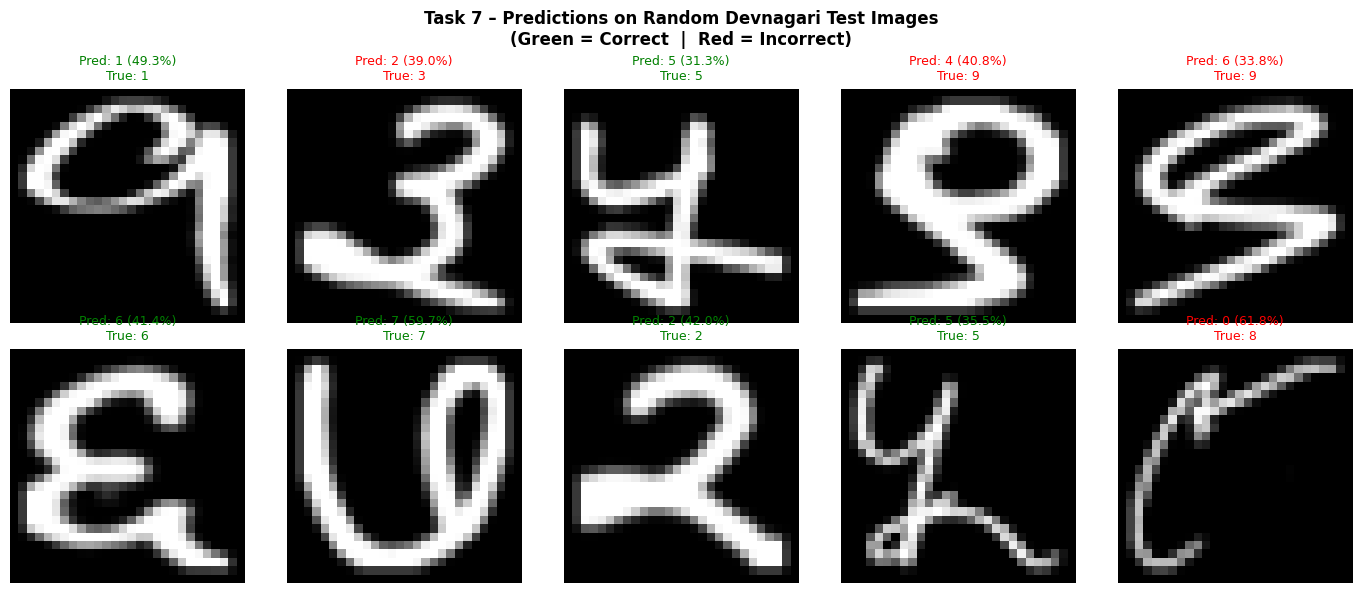

In [22]:
# 10 random test images with predictions
np.random.seed(0)
sample_idx = np.random.choice(len(x_test), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, idx in zip(axes.flatten(), sample_idx):
    img  = x_test[idx].reshape(IMG_HEIGHT, IMG_WIDTH)
    pred = predicted_labels[idx]
    true = true_labels[idx]
    conf = predictions[idx][pred] * 100
    color = 'green' if pred == true else 'red'
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {pred} ({conf:.1f}%)\nTrue: {true}",
                 fontsize=9, color=color)
    ax.axis('off')

plt.suptitle(
    'Task 7 – Predictions on Random Devnagari Test Images\n'
    '(Green = Correct  |  Red = Incorrect)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

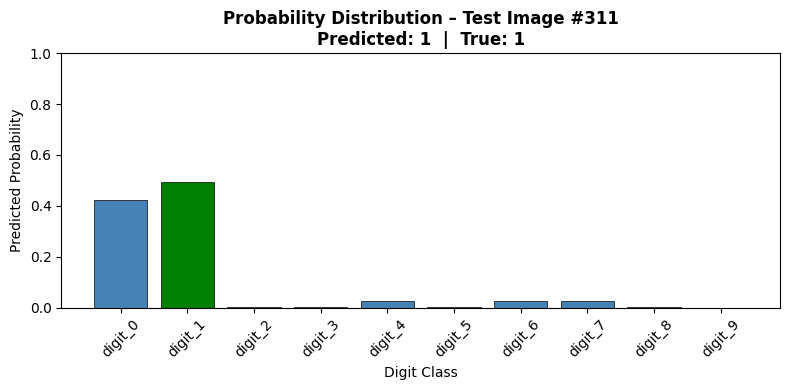

In [23]:
# Probability bar chart for one image
idx        = sample_idx[0]
prob_vec   = predictions[idx]
pred_digit = predicted_labels[idx]
true_digit = true_labels[idx]

colors = ['steelblue'] * 10
colors[pred_digit] = 'green'
if true_digit != pred_digit:
    colors[true_digit] = 'orange'

plt.figure(figsize=(8, 4))
plt.bar(range(10), prob_vec, color=colors, edgecolor='black', linewidth=0.5)
plt.xticks(range(10), [f'digit_{i}' for i in range(10)], rotation=45)
plt.xlabel('Digit Class'); plt.ylabel('Predicted Probability')
plt.ylim(0, 1)
plt.title(
    f'Probability Distribution – Test Image #{idx}\n'
    f'Predicted: {pred_digit}  |  True: {true_digit}',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## Final Summary

In [27]:
total_correct = int(np.sum(predicted_labels == true_labels))
overall_acc   = total_correct / len(true_labels)

print(f"\n  Task 1 - Data Preparation    COMPLETE")
print(f"    Train images  : {x_train.shape[0]:,}  shape {x_train.shape[1:]}")
print(f"    Test  images  : {x_test.shape[0]:,}   shape {x_test.shape[1:]}")
print(f"    Normalised to [0,1]  |  One-hot encoded")
print(f"\n  Task 2 - Model Built         COMPLETE")
print(f"    Type          : Sequential FCN")
print(f"    Hidden layers : 64 -> 128 -> 256 (sigmoid)")
print(f"    Output        : 10 neurons, softmax")
print(f"    Total params  : {model.count_params():,}")
print(f"\n  Task 3 - Compiled            COMPLETE")
print(f"    Optimizer : Adam  |  Loss : categorical_crossentropy")
print(f"\n  Task 4 - Trained             COMPLETE")
print(f"    Epochs run      : {len(history.history['loss'])} / {EPOCHS}")
print(f"    Train accuracy  : {train_acc[-1]*100:.2f}%")
print(f"    Val   accuracy  : {val_acc[-1]*100:.2f}%")
print(f"\n  Task 5 - Evaluated           COMPLETE")
print(f"    Test Loss     : {test_loss:.4f}")
print(f"    Test Accuracy : {test_acc*100:.2f}%")
print(f"\n  Task 6 - Saved & Loaded      COMPLETE")
print(f"    File          : devnagari_fcn_model.h5")
print(f"    Loaded acc    : {loaded_acc*100:.2f}%  (matches original)")
print(f"\n  Task 7 - Predictions         COMPLETE")
print(f"    Correct       : {total_correct:,} / {len(true_labels):,}")
print(f"    Accuracy      : {overall_acc*100:.2f}%")


  Task 1 - Data Preparation    COMPLETE
    Train images  : 17,000  shape (28, 28, 1)
    Test  images  : 3,000   shape (28, 28, 1)
    Normalised to [0,1]  |  One-hot encoded

  Task 2 - Model Built         COMPLETE
    Type          : Sequential FCN
    Hidden layers : 64 -> 128 -> 256 (sigmoid)
    Output        : 10 neurons, softmax
    Total params  : 94,154

  Task 3 - Compiled            COMPLETE
    Optimizer : Adam  |  Loss : categorical_crossentropy

  Task 4 - Trained             COMPLETE
    Epochs run      : 6 / 20
    Train accuracy  : 96.51%
    Val   accuracy  : 0.00%

  Task 5 - Evaluated           COMPLETE
    Test Loss     : 2.1636
    Test Accuracy : 61.70%

  Task 6 - Saved & Loaded      COMPLETE
    File          : devnagari_fcn_model.h5
    Loaded acc    : 61.70%  (matches original)

  Task 7 - Predictions         COMPLETE
    Correct       : 1,851 / 3,000
    Accuracy      : 61.70%



## Conclusion

This worksheet showed a complete end-to-end deep learning pipeline for Devnagari handwritten digit classification:

